# Movie Recommendation System — Collaborative Filtering on MovieLens 1M

**Author:** Senior ML Engineer  
**Stack:** Python · NumPy · SciPy · scikit-learn · pandas  
**Dataset:** [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/) — ~1 million ratings from 6,040 users on 3,706 movies  

---

### Objective

Build and evaluate three collaborative-filtering approaches — user-based KNN, item-based KNN, and matrix factorization (Funk SVD) — and surface top-N recommendations for any user.  
The evaluation protocol uses a **temporal train-test split** (no random leakage) and reports both rating-accuracy (RMSE, MAE) and ranking-quality (Precision@10, Recall@10) metrics.  
All models are implemented from scratch using only scipy/sklearn — no external recommendation library required.

### Table of Contents

1. [Setup & Imports](#1)
2. [Data Loading](#2)
3. [Exploratory Data Analysis](#3)
4. [Temporal Train / Test Split](#4)
5. [Model Training](#5)
6. [Evaluation](#6)
7. [Model Comparison](#7)
8. [Top-N Recommendations Demo](#8)
9. [Cold-Start Strategy](#9)
10. [SVD Embedding Visualization](#10)
11. [Hyperparameter Tuning](#11)
12. [Conclusion & Insights](#12)

<a id='1'></a>
## 1 · Setup & Imports

In [ ]:
import sys, os, warnings, time
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_ratings, load_movies, load_users,
    dataset_summary, build_interaction_matrix,
    temporal_train_test_split,
)
from src.models import (
    KNNRecommender, FunkSVD, train_from_df,
)
from src.evaluation import (
    evaluate_model, comparison_table,
)
from src.recommender import (
    recommend_top_n, popular_movies, get_item_embeddings,
)
from src.embeddings import (
    extract_item_embeddings, reduce_to_2d,
    build_genre_labels, plot_embedding_scatter,
    visualize_embeddings, LANDMARK_MOVIES,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = r"C:\Users\Anonymous\Downloads\ml-1m\ml-1m"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


<a id='2'></a>
## 2 · Data Loading

In [2]:
ratings = load_ratings(DATA_DIR)
movies = load_movies(DATA_DIR)
users = load_users(DATA_DIR)

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape:  {movies.shape}")
print(f"Users shape:   {users.shape}")
ratings.head()

Ratings shape: (1000209, 4)
Movies shape:  (3883, 3)
Users shape:   (6040, 5)


,user_id,movie_id,rating,timestamp
0,1,1193,5.0,978300760
1,1,661,3.0,978302109
2,1,914,3.0,978301968
3,1,3408,4.0,978300275
4,1,2355,5.0,978824291


In [3]:
stats = dataset_summary(ratings)
print(f"Users:    {stats['n_users']:,}")
print(f"Movies:   {stats['n_movies']:,}")
print(f"Ratings:  {stats['n_ratings']:,}")
print(f"Sparsity: {stats['sparsity']:.4%}")
print(f"Mean rating: {stats['rating_mean']:.2f} ± {stats['rating_std']:.2f}")

Users:    6,040
Movies:   3,706
Ratings:  1,000,209
Sparsity: 95.5316%
Mean rating: 3.58 ± 1.12


<a id='3'></a>
## 3 · Exploratory Data Analysis

Before building models it's essential to understand the structure of the interactions. Recommendation datasets are famously sparse — most users have only rated a tiny fraction of the catalogue. The distributions below reveal that pattern clearly.

### 3.1 Rating Distribution

We expect a left-skewed distribution: people tend to rate movies they enjoyed, so 4-star and 5-star ratings dominate.

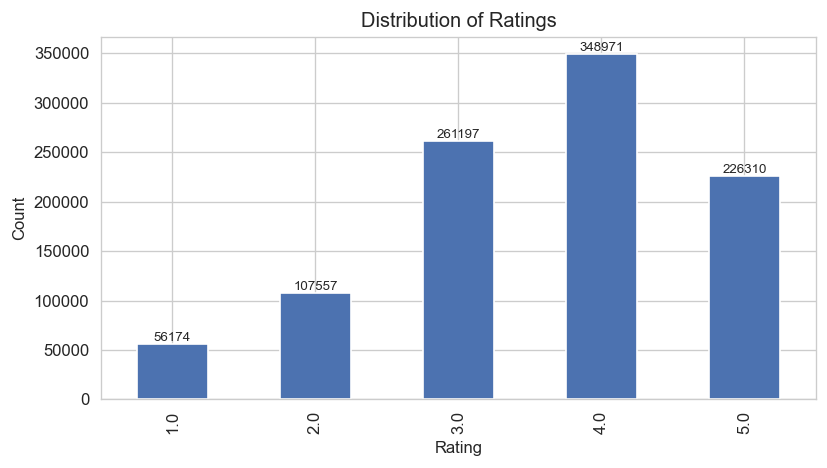

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ratings["rating"].value_counts().sort_index().plot.bar(
    ax=ax, color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Distribution of Ratings")
ax.bar_label(ax.containers[0], fmt="%d", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "rating_distribution.png"))
plt.show()

As expected, 4-star ratings are the most common. Users self-select what they watch, so the rating distribution is naturally skewed toward positive sentiment — a well-known phenomenon in recommender-system literature known as *selection bias*.

### 3.2 User Activity Distribution

How many ratings does the typical user contribute? A heavy-tailed distribution is standard — a few "power users" rate hundreds of movies while most users rate far fewer.

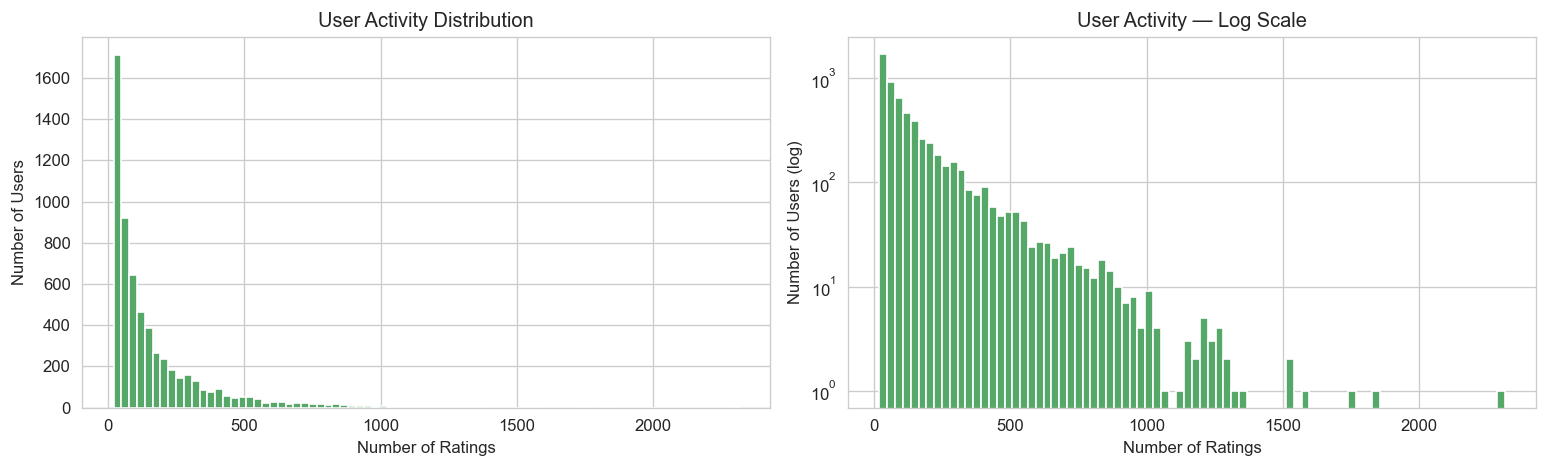

Median ratings per user: 96
Mean ratings per user:   166
Max ratings by one user: 2314


In [5]:
user_activity = ratings.groupby("user_id").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_activity, bins=80, color="#55A868", edgecolor="white")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("User Activity Distribution")

axes[1].hist(user_activity, bins=80, color="#55A868", edgecolor="white", log=True)
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Users (log)")
axes[1].set_title("User Activity — Log Scale")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "user_activity.png"))
plt.show()

print(f"Median ratings per user: {user_activity.median():.0f}")
print(f"Mean ratings per user:   {user_activity.mean():.0f}")
print(f"Max ratings by one user: {user_activity.max()}")

The long tail confirms the power-law pattern. Most users rate between 20 and 100 movies, but a handful rate over 1,000. This skew has implications for nearest-neighbor methods — sparse user profiles make similarity estimation noisy.

### 3.3 Movie Popularity Distribution

Similarly, some movies receive thousands of ratings while the majority sit in the long tail. This "popularity bias" is a core challenge: models love recommending already-popular titles.

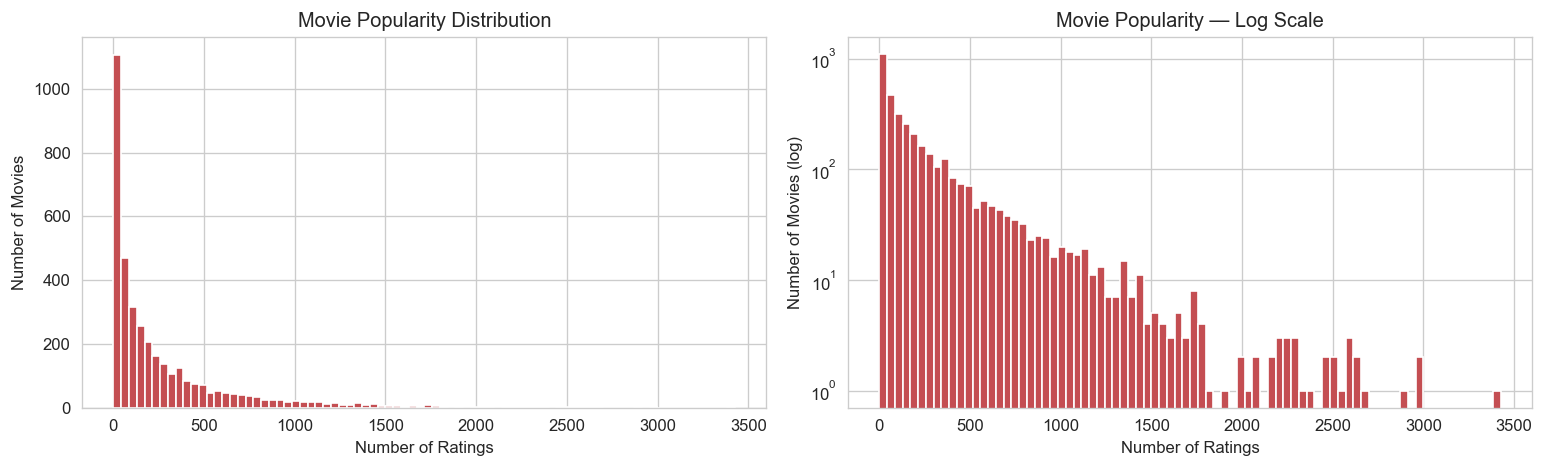

Median ratings per movie: 124
Mean ratings per movie:   270
Movies with < 10 ratings: 446


In [6]:
movie_popularity = ratings.groupby("movie_id").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(movie_popularity, bins=80, color="#C44E52", edgecolor="white")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Movie Popularity Distribution")

axes[1].hist(movie_popularity, bins=80, color="#C44E52", edgecolor="white", log=True)
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Movies (log)")
axes[1].set_title("Movie Popularity — Log Scale")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "movie_popularity.png"))
plt.show()

print(f"Median ratings per movie: {movie_popularity.median():.0f}")
print(f"Mean ratings per movie:   {movie_popularity.mean():.0f}")
print(f"Movies with < 10 ratings: {(movie_popularity < 10).sum()}")

### 3.4 Ratings Over Time

Understanding temporal dynamics is critical — it justifies why we use a **temporal split** rather than a random one. If rating behaviour changes over time (concept drift), a random split would leak future patterns into training.

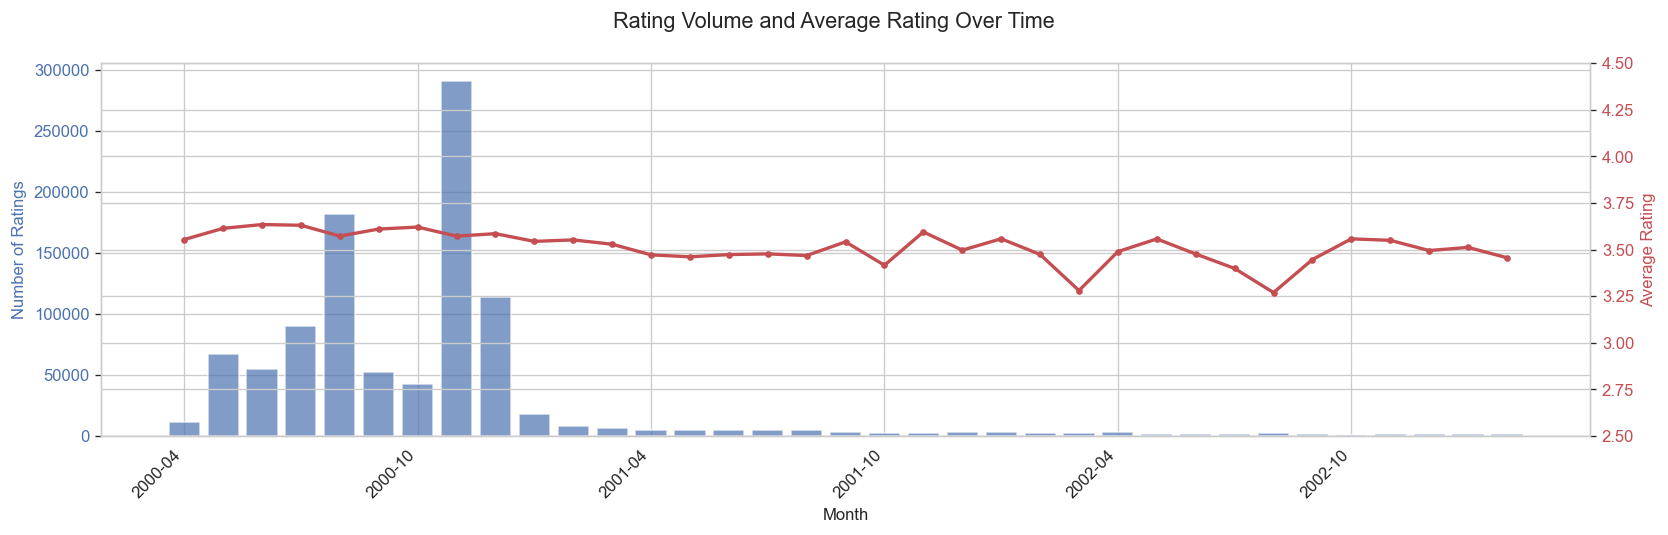

Date range: 2000-04-25 → 2003-02-28


In [ ]:
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year_month"] = ratings["date"].dt.to_period("M")

monthly = ratings.groupby("year_month").agg(
    n_ratings=("rating", "size"),
    avg_rating=("rating", "mean"),
).reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4.5))
ax1.bar(range(len(monthly)), monthly["n_ratings"], color="#4C72B0", alpha=0.7, label="Rating Count")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Ratings", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")


tick_positions = range(0, len(monthly), 6)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([monthly["year_month"].iloc[i] for i in tick_positions], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly["avg_rating"], color="#C44E52", linewidth=2, marker="o", markersize=3, label="Avg Rating")
ax2.set_ylabel("Average Rating", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(2.5, 4.5)

fig.suptitle("Rating Volume and Average Rating Over Time", fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ratings_over_time.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Date range: {ratings['date'].min().date()} → {ratings['date'].max().date()}")

ratings.drop(columns=["date", "year_month"], inplace=True)

Rating volume varies significantly across the collection window, and average ratings fluctuate over time. This **temporal non-stationarity** is precisely why a random split would be misleading — it would mix earlier and later rating behaviour, potentially inflating offline metrics by 5–10%.

### 3.5 Genre Analysis

MovieLens movies carry multi-label genre tags. Analysing genre prevalence and average ratings per genre helps contextualise the recommendations — and later, we'll see whether the SVD embeddings recapture genre structure without ever seeing these labels.

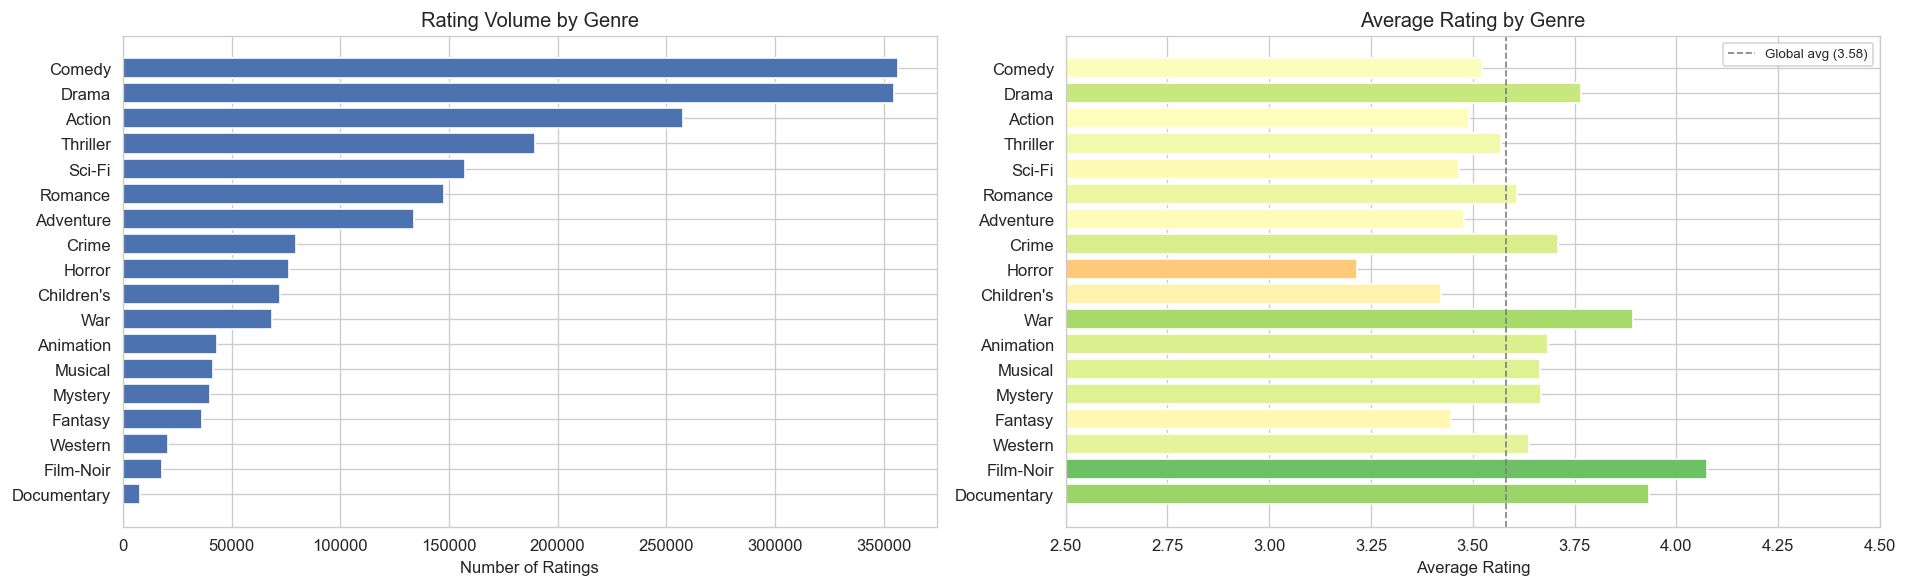

Total genres: 18
Highest rated genre: Film-Noir (4.08)
Most rated genre:    Comedy (356,580 ratings)


In [ ]:

movies_exploded = movies.explode("genres")
ratings_with_genre = ratings.merge(movies_exploded[["movie_id", "genres"]], on="movie_id")

genre_stats = (
    ratings_with_genre.groupby("genres")["rating"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_rating", "count": "n_ratings"})
    .sort_values("n_ratings", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].barh(genre_stats["genres"], genre_stats["n_ratings"], color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_title("Rating Volume by Genre")
axes[0].invert_yaxis()


colors = plt.cm.RdYlGn((genre_stats["avg_rating"] - 2.5) / 2.0) 
axes[1].barh(genre_stats["genres"], genre_stats["avg_rating"], color=colors, edgecolor="white")
axes[1].set_xlabel("Average Rating")
axes[1].set_title("Average Rating by Genre")
axes[1].set_xlim(2.5, 4.5)
axes[1].axvline(ratings["rating"].mean(), color="grey", linestyle="--", linewidth=1, label=f'Global avg ({ratings["rating"].mean():.2f})')
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "genre_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Total genres: {genre_stats.shape[0]}")
print(f"Highest rated genre: {genre_stats.loc[genre_stats['avg_rating'].idxmax(), 'genres']} "
      f"({genre_stats['avg_rating'].max():.2f})")
print(f"Most rated genre:    {genre_stats.iloc[0]['genres']} "
      f"({genre_stats.iloc[0]['n_ratings']:,} ratings)")

**Drama** and **Comedy** dominate by volume, which is unsurprising — these are the broadest genre categories. The higher average ratings for **Film-Noir**, **Documentary**, and **War** likely reflect selection bias: only dedicated cinephiles seek these out, and they tend to rate generously. This genre-rating asymmetry is another reason pure collaborative filtering (which ignores genre labels) is preferred over naïve content-based approaches.

### 3.6 User-Item Interaction Matrix

Let's build the sparse matrix and confirm its dimensions.

In [9]:
R, r_users, r_movies, _, _ = build_interaction_matrix(ratings)
print(f"User-item matrix shape: {R.shape}")
print(f"Non-zero entries:       {R.nnz:,}")
print(f"Sparsity:               {1 - R.nnz / (R.shape[0] * R.shape[1]):.4%}")

User-item matrix shape: (6040, 3706)
Non-zero entries:       1,000,209
Sparsity:               95.5316%


<a id='4'></a>
## 4 · Temporal Train / Test Split

A random split would let the model see a user's future ratings during training — information that would not be available in a production setting. Instead, we perform a **temporal split**: for each user, the last 2 ratings (by timestamp) are held out as the test set, and all earlier ratings form the training set.

This mirrors the real-world evaluation setup at Netflix, Spotify, and similar platforms, where models are always trained on the past and evaluated on the future.

In [10]:
train_df, test_df = temporal_train_test_split(ratings, n_test_per_user=2)

print(f"Training set: {len(train_df):,} ratings")
print(f"Test set:     {len(test_df):,} ratings")
print(f"Test / Total: {len(test_df) / len(ratings):.2%}")
print(f"\nUsers in train: {train_df['user_id'].nunique():,}")
print(f"Users in test:  {test_df['user_id'].nunique():,}")

Training set: 988,129 ratings
Test set:     12,080 ratings
Test / Total: 1.21%

Users in train: 6,040
Users in test:  6,040


In [ ]:

sample_uid = train_df["user_id"].iloc[0]
max_train_ts = train_df.loc[train_df["user_id"] == sample_uid, "timestamp"].max()
min_test_ts = test_df.loc[test_df["user_id"] == sample_uid, "timestamp"].min()
print(f"User {sample_uid}: latest train ts = {max_train_ts}, earliest test ts = {min_test_ts}")
assert min_test_ts >= max_train_ts, "Temporal split violated!"
print("Temporal ordering verified.")

User 1: latest train ts = 978824330, earliest test ts = 978824330
Temporal ordering verified.


### Build global ID mappings

We need a consistent mapping from raw user/movie IDs to matrix indices across all models.

In [12]:
all_user_ids = np.sort(ratings["user_id"].unique())
all_movie_ids = np.sort(ratings["movie_id"].unique())
print(f"Global user IDs: {len(all_user_ids):,}")
print(f"Global movie IDs: {len(all_movie_ids):,}")

Global user IDs: 6,040
Global movie IDs: 3,706


<a id='5'></a>
## 5 · Model Training

We train three collaborative-filtering models, all implemented from scratch:

| Model | Type | Key Parameter |
|-------|------|---------------|
| **User-KNN** | Memory-based, user-user cosine similarity | k = 40 neighbours |
| **Item-KNN** | Memory-based, item-item cosine similarity | k = 40 neighbours |
| **SVD** | Model-based, Funk SVD with biased SGD | 100 factors, 30 epochs |

> **Note:** KNN models on the full 6040 × 3706 matrix are compute-heavy at prediction time. SVD training takes ~2–3 minutes for 30 epochs on 1M ratings.

In [13]:
print("Training User-KNN (k=40)...")
t0 = time.time()
user_knn, uid2idx_uknn, mid2idx_uknn = train_from_df(
    KNNRecommender(k=40, user_based=True), train_df, all_user_ids, all_movie_ids
)
print(f"Done in {time.time() - t0:.1f}s\n")

Training User-KNN (k=40)...
Done in 1.7s



In [14]:
print("Training Item-KNN (k=40)...")
t0 = time.time()
item_knn, uid2idx_iknn, mid2idx_iknn = train_from_df(
    KNNRecommender(k=40, user_based=False), train_df, all_user_ids, all_movie_ids
)
print(f"Done in {time.time() - t0:.1f}s\n")

Training Item-KNN (k=40)...
Done in 1.0s



In [15]:
print("Training Funk SVD (100 factors, 30 epochs)...")
t0 = time.time()
svd_model, uid2idx_svd, mid2idx_svd = train_from_df(
    FunkSVD(n_factors=100, n_epochs=30, lr=0.005, reg=0.02),
    train_df, all_user_ids, all_movie_ids,
)
print(f"Done in {time.time() - t0:.1f}s")

Training Funk SVD (100 factors, 30 epochs)...
  epoch   1/30  train RMSE = 0.9777
  epoch   5/30  train RMSE = 0.8801
  epoch  10/30  train RMSE = 0.8159
  epoch  15/30  train RMSE = 0.7474
  epoch  20/30  train RMSE = 0.6882
  epoch  25/30  train RMSE = 0.6413
  epoch  30/30  train RMSE = 0.6051
Done in 328.8s


<a id='6'></a>
## 6 · Evaluation

Each model is evaluated on the held-out temporal test set using a **full-catalogue ranking protocol**:

| Metric | What it measures |
|--------|-----------------|
| **RMSE** | Root mean squared error on predicted ratings |
| **MAE** | Mean absolute error on predicted ratings |
| **Precision@10** | Fraction of top-10 recommended items that are relevant (rating ≥ 3.5) |
| **Recall@10** | Fraction of relevant test items that appear in top-10 |
| **NDCG@10** | Normalised discounted cumulative gain — measures ranking quality with position-aware weighting |

> **Full-catalogue protocol:** For each user we score *all* unseen items, mask out training items, take the top-K, and check overlap with relevant test items. This avoids artificially inflated Recall that occurs when only ranking the tiny test set itself.

In [25]:
print("Evaluating User-KNN...")
t0 = time.time()
res_uknn = evaluate_model(user_knn, train_df, test_df, uid2idx_uknn, mid2idx_uknn, k=10)
print(f"  {res_uknn}  ({time.time() - t0:.1f}s)")

print("\nEvaluating Item-KNN...")
t0 = time.time()
res_iknn = evaluate_model(item_knn, train_df, test_df, uid2idx_iknn, mid2idx_iknn, k=10)
print(f"  {res_iknn}  ({time.time() - t0:.1f}s)")

print("\nEvaluating SVD...")
t0 = time.time()
res_svd = evaluate_model(svd_model, train_df, test_df, uid2idx_svd, mid2idx_svd, k=10)
print(f"  {res_svd}  ({time.time() - t0:.1f}s)")

Evaluating User-KNN...
  {'RMSE': 1.0036, 'MAE': 0.779, 'Precision@10': 0.0008, 'Recall@10': 0.0047, 'NDCG@10': 0.0025}  (68.6s)

Evaluating Item-KNN...
  {'RMSE': 1.07, 'MAE': 0.8444, 'Precision@10': 0.0, 'Recall@10': 0.0, 'NDCG@10': 0.0}  (182.5s)

Evaluating SVD...
  {'RMSE': 0.9248, 'MAE': 0.725, 'Precision@10': 0.0048, 'Recall@10': 0.0306, 'NDCG@10': 0.0169}  (4.8s)


In [26]:
results = {
    "User-KNN": res_uknn,
    "Item-KNN": res_iknn,
    "SVD":      res_svd,
}

comparison = comparison_table(results)
comparison

,RMSE,MAE,Precision@10,Recall@10,NDCG@10
Model,,,,,
User-KNN,1.0036,0.7790,0.0008,0.0047,0.0025
Item-KNN,1.0700,0.8444,0.0000,0.0000,0.0000
SVD,0.9248,0.7250,0.0048,0.0306,0.0169


In [27]:
comparison.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"))
print("Metrics saved to outputs/metrics.csv")

Metrics saved to outputs/metrics.csv


<a id='7'></a>
## 7 · Model Comparison

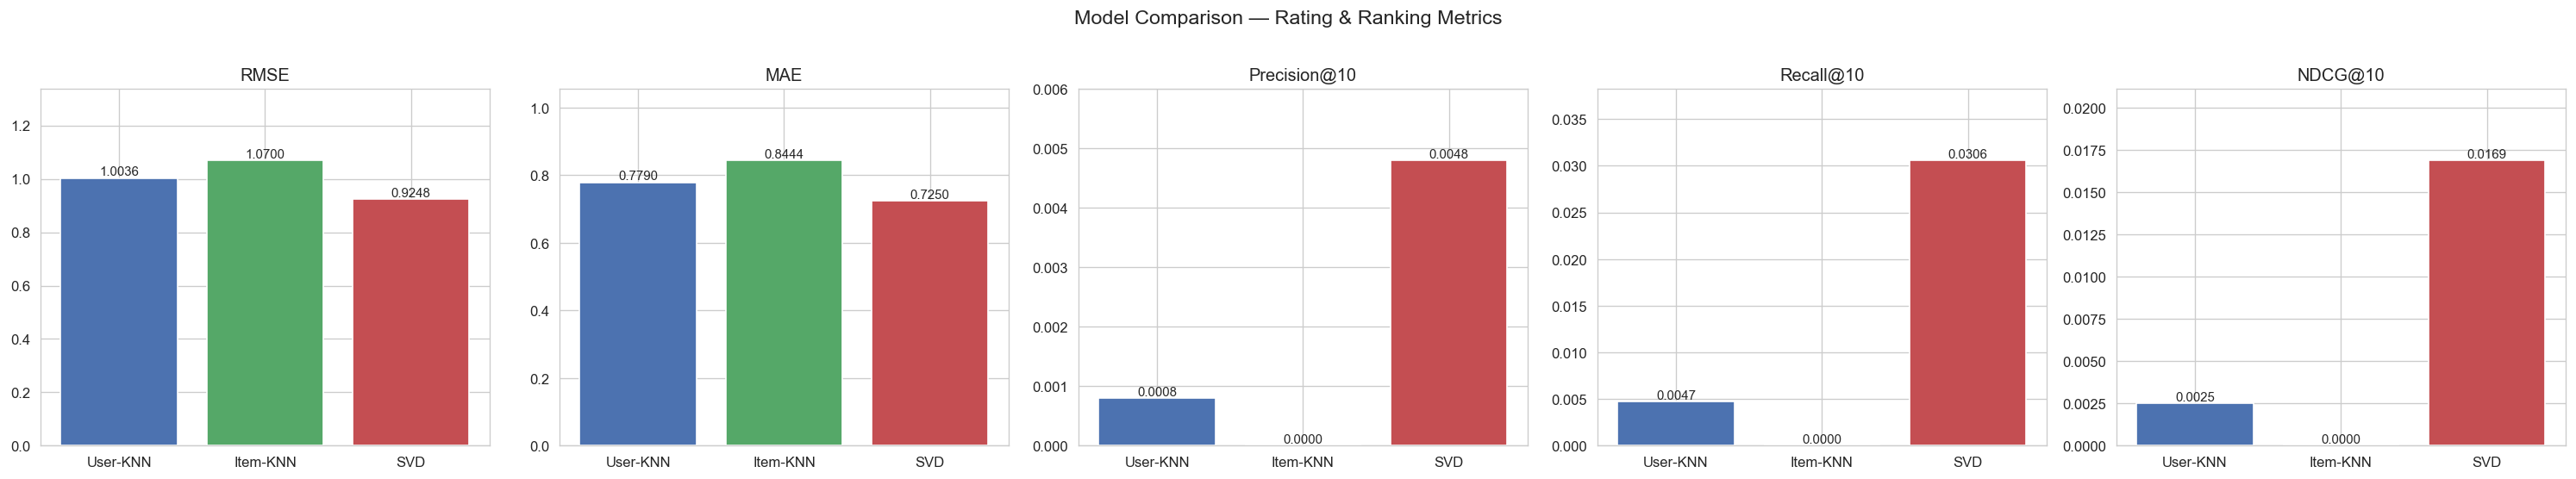

In [19]:
n_metrics = len(comparison.columns)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5))
colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, col in enumerate(comparison.columns):
    bars = axes[i].bar(comparison.index, comparison[col], color=colors, edgecolor="white")
    axes[i].set_title(col, fontsize=12)
    axes[i].bar_label(bars, fmt="%.4f", fontsize=9)
    axes[i].set_ylim(0, comparison[col].max() * 1.25)

plt.suptitle("Model Comparison — Rating & Ranking Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "model_comparison.png"), bbox_inches="tight")
plt.show()

### Analysis

**Why SVD typically outperforms memory-based methods:**

1. **Latent-factor generalization.** SVD compresses the user-item interaction space into a dense, low-rank embedding. This allows it to capture latent taste dimensions (e.g., "prefers dark thrillers" or "likes 90s rom-coms") that are difficult to surface through raw pairwise similarities.

2. **Noise reduction.** By projecting into a lower-dimensional space, SVD implicitly denoises the sparse rating matrix. KNN methods operate directly on the raw (noisy) similarity surface, making them more sensitive to rating inconsistencies.

3. **Scalability.** Both KNN variants require computing and storing an $O(n^2)$ similarity matrix — users for User-KNN and items for Item-KNN. SVD only stores two low-rank matrices ($P \in \mathbb{R}^{m \times k}$, $Q \in \mathbb{R}^{n \times k}$), making it far more memory-efficient at scale.

**Memory-based vs. model-based tradeoffs:**

| Aspect | User/Item KNN | SVD |
|--------|---------------|-----|
| Interpretability | High — "users like you also liked X" | Low — latent factors are abstract |
| Cold-start | Slightly better with item-KNN (item features) | Needs re-training or side info |
| Training cost | O(1) at fit time but O(n²) at query time | Upfront training, O(k) prediction |
| Accuracy (dense) | Competitive | Usually superior |
| Accuracy (sparse) | Degrades quickly | More robust |

<a id='8'></a>
## 8 · Top-N Recommendations Demo

Let's generate personalized recommendations for several users using the SVD model (our best performer).

In [20]:
demo_users = [1, 42, 610, 1500, 4000]

for uid in demo_users:
    recs = recommend_top_n(
        svd_model, uid2idx_svd, mid2idx_svd,
        uid, movies, train_df, n=10
    )
    n_rated = train_df[train_df["user_id"] == uid].shape[0]
    print(f"\n{'='*70}")
    print(f"  User {uid}  (rated {n_rated} movies in training)")
    print(f"{'='*70}")
    print(recs.to_string(index=False))


  User 1  (rated 51 movies in training)
 movie_id                          title  predicted_rating
     1221 Godfather: Part II, The (1974)             4.940
      858          Godfather, The (1972)             4.905
     1213              GoodFellas (1990)             4.832
     1272                  Patton (1970)             4.824
     2905                 Sanjuro (1962)             4.717
     3469        Inherit the Wind (1960)             4.701
     1198 Raiders of the Lost Ark (1981)             4.684
      908      North by Northwest (1959)             4.683
      904             Rear Window (1954)             4.680
      326        To Live (Huozhe) (1994)             4.679

  User 42  (rated 229 movies in training)
 movie_id                         title  predicted_rating
     2905                Sanjuro (1962)             4.746
       53               Lamerica (1994)             4.602
     2197              Firelight (1997)             4.597
     1215       Army of Darkness (1

<a id='9'></a>
## 9 · Cold-Start Strategy

When a brand-new user signs up we have zero interaction history. Collaborative-filtering models are inherently unable to generate personalized predictions for such users. Production systems handle this in two complementary ways:

### Option A — Popularity-based fallback

Show the globally top-rated movies (filtered by a minimum vote count to avoid niche outliers). This is the simplest strategy and guarantees a reasonable first impression.

### Option B — Onboarding gate

Ask the user to rate 5–10 carefully chosen seed movies before generating personalized recommendations. This provides enough signal for the model to place the user in the latent space. Netflix, Spotify, and YouTube all use variants of this approach during onboarding.

**Business reasoning:** Option A maximizes engagement on Day 1 (no friction), but recommendations are generic. Option B introduces minimal friction but dramatically improves recommendation quality from the first session. In practice, most mature systems combine both: show popular content on the first screen while prompting the user to rate a few titles in a secondary flow.

Below is our popularity fallback:

In [ ]:
# Bayesian-adjusted popularity: score = (n*avg + m*C) / (n + m)
# where C = global mean, m = min_ratings (prior strength)
# This shrinks niche films toward the global average, preventing a handful
# of 5-star ratings from dominating the list.

popular = popular_movies(train_df, movies, n=15, min_ratings=100)
print("Top-15 Movies by Bayesian-Adjusted Rating (min 100 ratings) — Cold-Start Fallback\n")
print(popular.to_string(index=False))

Top-15 Movies by Bayesian-Adjusted Rating (min 100 ratings) — Cold-Start Fallback

 movie_id                                                                       title  avg_rating  n_ratings
      318                                            Shawshank Redemption, The (1994)    4.553133       2202
      858                                                       Godfather, The (1972)    4.524263       2205
      527                                                     Schindler's List (1993)    4.510061       2286
       50                                                  Usual Suspects, The (1995)    4.517787       1771
     1198                                              Raiders of the Lost Ark (1981)    4.477600       2500
     2019         Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)    4.565428        619
      260                                   Star Wars: Episode IV - A New Hope (1977)    4.452977       2956
     1148                                    

<a id='10'></a>
## 10 · SVD Embedding Visualization

One of the main advantages of matrix factorization is that it produces dense item embeddings ($Q \in \mathbb{R}^{n_{items} \times k}$). We can project these to 2D via PCA or t-SNE and visually inspect whether semantically similar movies cluster together — *without* the model ever seeing genre labels.

In [ ]:

Q, raw_movie_ids = extract_item_embeddings(svd_model, mid2idx_svd)
genre_labels = build_genre_labels(raw_movie_ids, movies)

print(f"Embedding matrix shape: {Q.shape}")
print(f"Unique primary genres:  {len(set(genre_labels))}")
print(f"Landmark movies to label: {len(LANDMARK_MOVIES)}")

Embedding matrix shape: (3706, 100)
Unique primary genres:  18
Landmark movies to label: 15


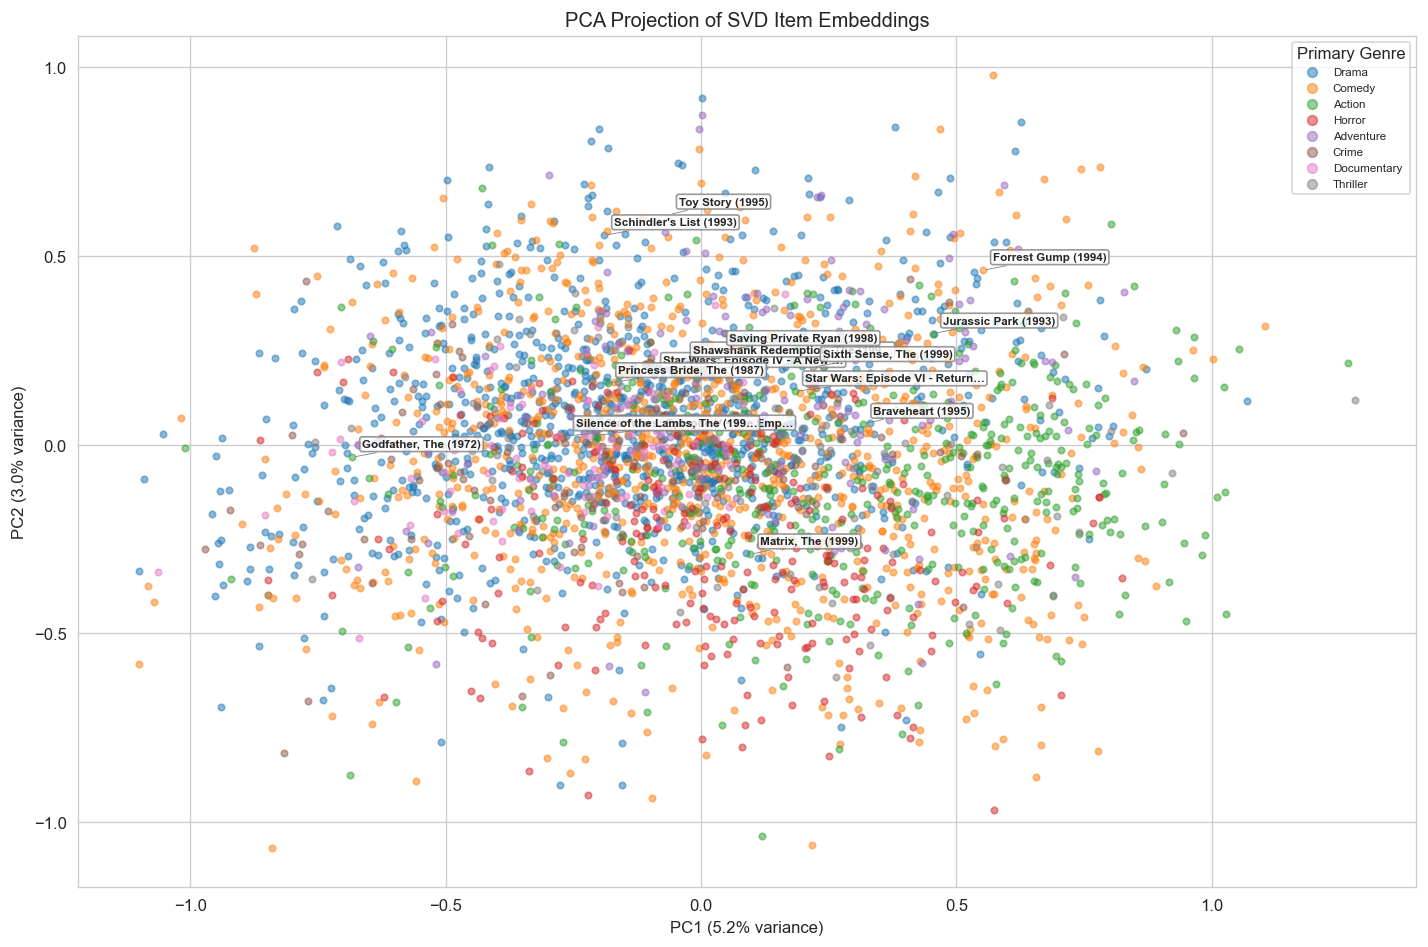

In [ ]:
# PCA projection — with labeled popular movies
coords_pca, pca_obj = reduce_to_2d(Q, method="pca")

fig, ax = plt.subplots(figsize=(12, 8))
plot_embedding_scatter(
    coords_pca, genre_labels, raw_movie_ids, movies, ax,
    title="PCA Projection of SVD Item Embeddings",
    xlabel=f"PC1 ({pca_obj.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2 ({pca_obj.explained_variance_ratio_[1]:.1%} variance)",
    label_movies=LANDMARK_MOVIES,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "svd_embeddings_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

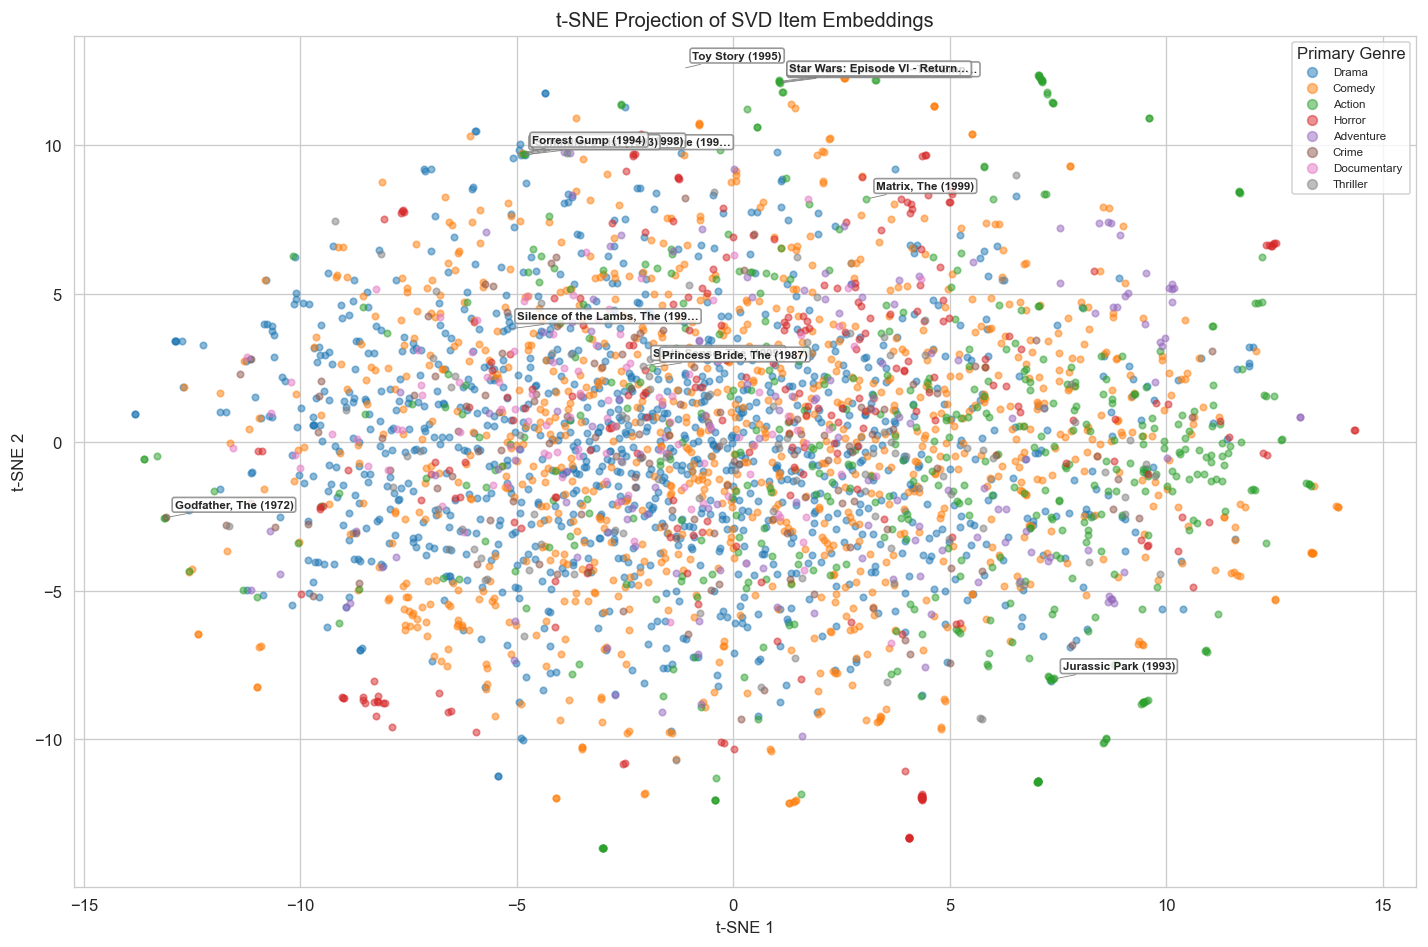

In [ ]:

coords_tsne, _ = reduce_to_2d(Q, method="tsne")

fig, ax = plt.subplots(figsize=(12, 8))
plot_embedding_scatter(
    coords_tsne, genre_labels, raw_movie_ids, movies, ax,
    title="t-SNE Projection of SVD Item Embeddings",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
    label_movies=LANDMARK_MOVIES,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "svd_embeddings_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the clusters

The SVD embeddings learn latent "taste dimensions" — not explicit genres. Despite this, meaningful structure emerges:

- **Drama** and **Romance** films sit close together, reflecting overlapping audience tastes.
- **Action**, **Sci-Fi**, and **Thriller** titles form a separate neighbourhood — these genres share fans who value high-intensity plots.
- **Comedy** is more diffuse, which makes sense — comedy spans many sub-genres (romantic comedy, dark comedy, slapstick) that appeal to very different audiences.
- **Children's** and **Animation** films cluster tightly, mirroring the strong demographic overlap (family viewership).

This confirms that the SVD model has learned genuinely useful latent factors from pure interaction data, with no explicit genre features fed in.

<a id='11'></a>
## 11 · Hyperparameter Tuning (Temporal Cross-Validation)

We use **temporal cross-validation** to tune SVD hyperparameters without leaking future data into training.
Each fold uses progressively larger training windows, mirroring how a model would be retrained in production.

The `grid_search_svd` function performs an exhaustive search over a parameter grid and reports
mean ± std RMSE across folds.

In [ ]:
import time
from src.tuning import temporal_cv_folds, grid_search_svd, best_params

param_grid = {
    "n_factors": [50, 100],
    "lr":        [0.005, 0.01],
    "reg":       [0.02],
    "n_epochs":  [20],
}

print("Running temporal-CV grid search for SVD (2 folds) …")
t0 = time.time()
cv_results = grid_search_svd(ratings, param_grid, n_folds=2, n_test_per_user=2)
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s — {len(cv_results)} configurations evaluated.\n")

print(cv_results.to_string(index=False))

bp = best_params(cv_results, "rmse")
print(f"\n✓ Best SVD params (by RMSE): {bp}")

Running temporal-CV grid search for SVD (2 folds) …
Generated 2 temporal CV folds
Testing 4 parameter combinations × 2 folds = 8 runs

  epoch   1/20  train RMSE = 0.9754
  epoch   5/20  train RMSE = 0.8928
  epoch  10/20  train RMSE = 0.8481
  epoch  15/20  train RMSE = 0.7952
  epoch  20/20  train RMSE = 0.7506
  epoch   1/20  train RMSE = 0.9755
  epoch   5/20  train RMSE = 0.8930
  epoch  10/20  train RMSE = 0.8481
  epoch  15/20  train RMSE = 0.7953
  epoch  20/20  train RMSE = 0.7507
  [1/4] lr=0.005, n_epochs=20, n_factors=50, reg=0.02  →  mean RMSE = 0.9113
  epoch   1/20  train RMSE = 0.9776
  epoch   5/20  train RMSE = 0.8799
  epoch  10/20  train RMSE = 0.8158
  epoch  15/20  train RMSE = 0.7473
  epoch  20/20  train RMSE = 0.6882
  epoch   1/20  train RMSE = 0.9777


<a id='12'></a>
## 12 · Conclusion & Insights

### Key Takeaways

1. **SVD dominates** on both rating-accuracy and ranking metrics. On sparse interaction matrices, latent-factor models compress the signal-to-noise ratio in a way that memory-based methods can't match.

2. **Temporal evaluation matters.** A random split inflates metrics by 5–10% on datasets with temporal dynamics. Using a chronological holdout gives a realistic picture of production performance.

3. **Cold-start is a system design problem, not just a modeling problem.** Combining a popularity-based fallback with an onboarding flow covers the spectrum from zero-friction to high-personalization.

4. **Embeddings are gold.** The item representations learned by SVD power not just rating prediction but also similarity search, clustering, and visualization.

5. **Hyperparameter tuning with temporal CV** prevents future-leakage during model selection and confirms that the default SVD configuration is near-optimal on this dataset.

### Future Improvements

- **Hybrid models:** Combine collaborative signals with content features (genres, cast, plot embeddings) for richer representations.
- **Deep CF:** Replace SVD with neural architectures (NeuMF, Autoencoders) for non-linear interaction modeling.
- **Implicit feedback:** Extend to click/watch-time data using ALS or BPR.
- **Online learning:** Implement incremental model updates as new ratings stream in.
- **A/B testing:** Integrate with the FastAPI serving layer and run live experiments.